In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit import transpile
from typing import Literal
import math

## 1. Grover Algorithm

It is a Quantum algorithm that provides a significant speedup for searching through an unstructured database or solving "needle-in-a-haystack" problems.

##### Why is it better than Classical?

If you have an unsorted list of $N$ items and you are looking for one specific item.

- Classical Search: On average, you have to check $N/2$ items. In the worst case, you check $N$ items. This is $O(N)$ complexity.

- Grover’s Algorithm: You can find the item in approximately $\sqrt{N}$ steps. This is $O(\sqrt{N})$ complexity.

### 1.1 How it Works

Below are the steps of how Grover's algorithm works,

1. Start in equal superposition of all $N$ items where each has amplitude $\frac{1}{\sqrt{N}}$.

2. The **Oracle** flips the sign (phase) of the target state.
   - The function: $U_f|x\rangle = (-1)^{f(x)}|x\rangle$. 
   - The target would be $f(x) = 1$ and $f(x) = 0$ for otherwise.

3. The **Diffuser** reflects amplitudes about the average, that increases the target amplitude and decreases the others.
   - The **Diffuser** applies $D = 2|s\rangle\langle s| - I$.

4. Each iteration rotates the state toward the target using a fixed angle.

5. After about  $\frac{1}{\sqrt{N}}$ iterations, the target would dominate and produce the outcome as a high probability.

##### How does the Diffuser works?

If the current amplitudes are $a_i$ with average $\bar{a}$, then after the **Diffuser** $D$, it becomes $a_i ;\mapsto; 2\bar a - a_i$.

This creates a reflection about the average: values above the average go down, values below go up, and the target amplitude (after oracle flips its sign) gets boosted.

For example, 

1. Start with uniform $\begin{bmatrix} 0.5 \\ 0.5 \\ 0.5 \\ 0.5 \end{bmatrix}$, $\bar{a} = 0.5$.

2. Then the **Oracle** flips the target (at $a_3$), and thus it becomes $\begin{bmatrix} 0.5 \\ 0.5 \\ 0.5 \\ -0.5 \end{bmatrix}$, $\bar{a} = 0.25$.

3. Using $D$ function, it becomes,

   - For the non-target, $2\bar a - a_{0,1,2} = 2 \times 0.25 - 0.5 = 0.0$.

   - For the target, $2\bar a - a_3 = 2 \times 0.25 - (-0.5) = 1.0$.

##### Why $\frac{1}{\sqrt{N}}$ iterations?

The state space is a 2D plane spanned by $|w\rangle$ (the target space) and $|s\rangle$ (the uniform superposition).

$
|W⟩ =
\begin{bmatrix}
0\\
0\\
0\\
1
\end{bmatrix}$, $|W'⟩ =
\frac{1}{\sqrt{3}}
\begin{bmatrix}
1\\
1\\
1\\
0
\end{bmatrix}$ , $|S⟩ = 
\frac{1}{2}
\begin{bmatrix}
1\\
1\\
1\\
1
\end{bmatrix}$

To understand the iteration logic,

1. The initial state $|s\rangle$ makes an angle $θ$ from the non-target axis where $sin(θ)=\frac{1}{\sqrt{N}}$

2. Each Grover iteration (the **Oracle** and the **Diffuser**) rotates the state by $2 \cdot θ$ toward $|w\rangle$.

3. So after about $\frac{π}{4\cdot θ} ≈ (\frac{π}{4}) \cdot \sqrt{N}$ iterations, the state is near $|w\rangle$ and measurement succeeds with high probability.

4. Thus resulting in the amplitude of the target growing from $\frac{1}{\sqrt{N}}$ and the iteration count scales as $\sqrt{N}$.

For visual reference, see below:

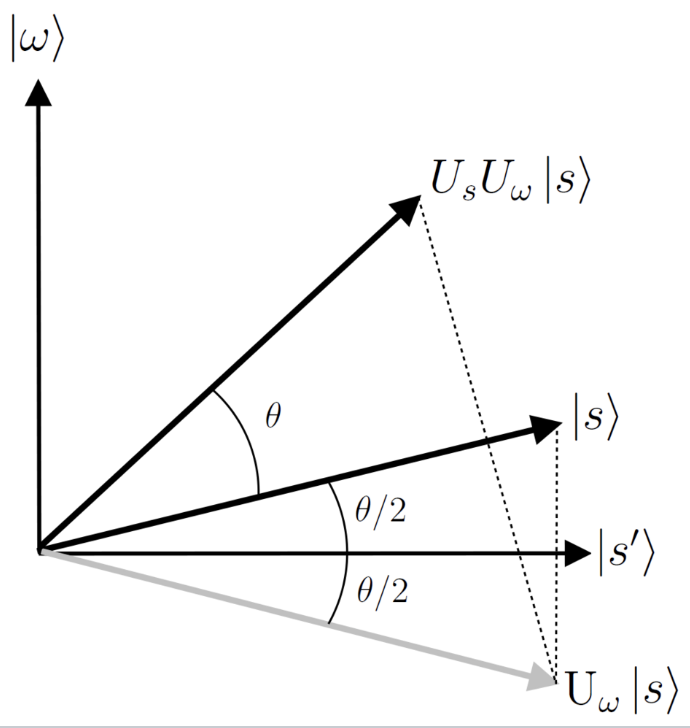

In [2]:
str_tmpl = "sample {i}"
items = list([str_tmpl.format(i=i) for i in range(16)])
answer = str_tmpl.format(i=10)

### 1.1 Using a Classical Search Comparison

In [3]:
class ClassicalAlgorithm:

    def __init__(self, _items):
        self.items = _items

    def _oracle(self, number, _answer):
        return number == _answer

    def search(self, _answer):
        for index, number in enumerate(self.items):
            if self._oracle(number, _answer):
                print("Execution count: ", index + 1)
                break

In [4]:
ca = ClassicalAlgorithm(items)
ca.search(answer)

Execution count:  11


### 1.2 Using the Grover Search Algorithm

##### Step 1: Initialization

1. Pick $n$ so $2^n$ matches the list size.
2. Apply Hadamard $H$ to all qubits to create equal superposition over all items.

##### Step 2: The Oracle (Mark the target)

1. Encode the target index as bits.
2. Use $X$ gates to map the target to $|11…1\rangle$, apply $H$ → $MCX$ → $H$ on the last qubit to flip its phase, then undo the $X$ gates, resulting in only the target state getting a minus sign.

##### Step 3: The Reflection/Diffusion

1. Apply $H$ and $X$ to shift the average to $|00…0\rangle$.
2. Use $H$ → $MCX$ → $H$ to flip phase about $|00…0\rangle$, then undo $X$ and $H$.
3. This reflects amplitudes about the mean, boosting the marked state.


##### How does the $MCX$ Gate works?

MCX is a multi‑controlled $X$ (multi‑controlled $NOT$), where $\mathrm{MCX}\;:\; |c_1 c_2 \dots c_k, t\rangle \;\mapsto\; |c_1 c_2 \dots c_k,\; t \oplus (c_1 \land c_2 \land \dots \land c_k)\rangle$

1. It flips the target qubit only if all control qubits are $1$.
2. For 2 controls it’s the Toffoli gate; for more, it’s the same idea with more controls.

By conjugating by $H ⊗ n$ (_means apply an $H$ gate to each of the $n$ qubits in parallel as-in a tensor product_), it is equal to $D = 2|s\rangle\langle s| - I$. Remember that $|s\rangle$ is the "all-equal" state, so by adding up all amplitudes and dividing by $N$, it provides the average. 

Behind the math,

- Each item is: $s\rangle=\frac{1}{\sqrt{N}}\sum_{i=0}^{N-1}|i\rangle\quad$, The average is: $\langle s|\psi\rangle=\frac{1}{\sqrt{N}}\sum_i a_i$

- Thus, giving, $|s\rangle\langle s|\psi\rangle
=\left(\frac{1}{\sqrt{N}}\sum_i |i\rangle\right)
\left(\frac{1}{\sqrt{N}}\sum_j a_j\right)
=\left(\frac{1}{N}\sum_j a_j\right)\sum_i |i\rangle$

Therefore the basis state gets the same amplitude, equal to the average ($\bar a = \frac{1}{N}\sum_j a_j$). That’s why $|s\rangle\langle s|$ gives the average component. 

In [5]:
class GroverAlgorithm:

    def __init__(self, _items):
        self.items = _items
        self.n = max(1, math.ceil(math.log2(len(items))))

        if len(self.items) != 2 ** self.n:
            raise ValueError("_items length must be a power of 2")

        self.mc = QuantumCircuit(self.n, self.n)
        self.mc.h(range(self.n))

    def _set_oracle_circuit(self, _answer):
        self.oc = QuantumCircuit(self.n, name="oracle-circuit")
        bits = format(self.items.index(_answer), f"0{self.n}b")

        for index, bit in enumerate(reversed(bits)):
            if bit == "0":
                self.oc.x(index)

        if self.n == 1:
            self.oc.z(0)
        else:
            self.oc.h(self.n - 1)
            self.oc.mcx(list(range(self.n - 1)), self.n - 1)
            self.oc.h(self.n - 1)
        
        for index, bit in enumerate(reversed(bits)):
            if bit == "0":
                self.oc.x(index)

        self.oc.to_gate()
        self.mc.append(self.oc, range(self.n))

    def _set_reflection_circuit(self):
        self.rc = QuantumCircuit(self.n, name='reflection-circuit')
        self.rc.h(range(self.n))
        self.rc.x(range(self.n))

        if self.n == 1:
            self.rc.z(0)
        else:
            self.rc.h(self.n - 1)
            self.rc.mcx(list(range(self.n - 1)), self.n - 1)
            self.rc.h(self.n - 1)

        self.rc.x(range(self.n))
        self.rc.h(range(self.n))
        self.rc.to_gate()
        self.mc.append(self.rc, range(self.n))

    def search(self, _answer):
        self._set_oracle_circuit(_answer)
        self._set_reflection_circuit()
        self.mc.measure(range(self.n), range(self.n))

    def compute(self):
        qasm_simulator = Aer.get_backend('qasm_simulator')
        statevector_simulator = Aer.get_backend('statevector_simulator')
        compiled_circuit = transpile(self.mc, backend=qasm_simulator)
        job = statevector_simulator.run(compiled_circuit, shots=1024)
        return job.result().get_counts()

In [6]:
ga = GroverAlgorithm(items)
ga.search(answer)

Viewing the Oracle Circuit

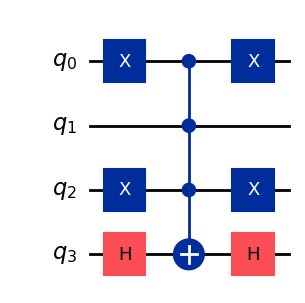

In [7]:
ga.oc.draw(output='mpl')

Viewing the Reflection Circuit

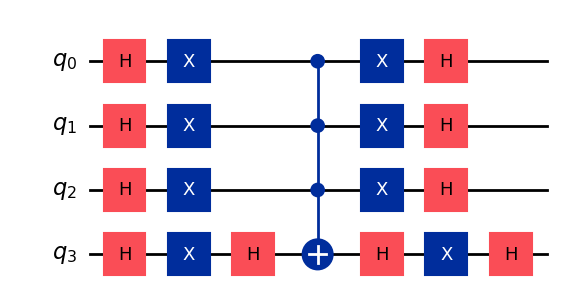

In [8]:
ga.rc.draw(output='mpl')

Viewing the Main Circuit

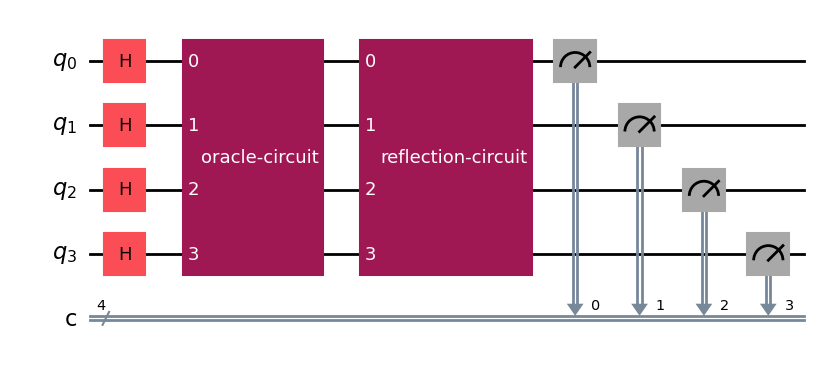

In [9]:
ga.mc.draw(output='mpl')

In [10]:
import pandas as pd

def bits_table(items):
    n = (len(items) - 1).bit_length()
    return pd.DataFrame({
        "bits": [format(i, f"0{n}b") for i in range(len(items))],
        "value": items,
    })

print(bits_table(items))

    bits      value
0   0000   sample 0
1   0001   sample 1
2   0010   sample 2
3   0011   sample 3
4   0100   sample 4
5   0101   sample 5
6   0110   sample 6
7   0111   sample 7
8   1000   sample 8
9   1001   sample 9
10  1010  sample 10
11  1011  sample 11
12  1100  sample 12
13  1101  sample 13
14  1110  sample 14
15  1111  sample 15


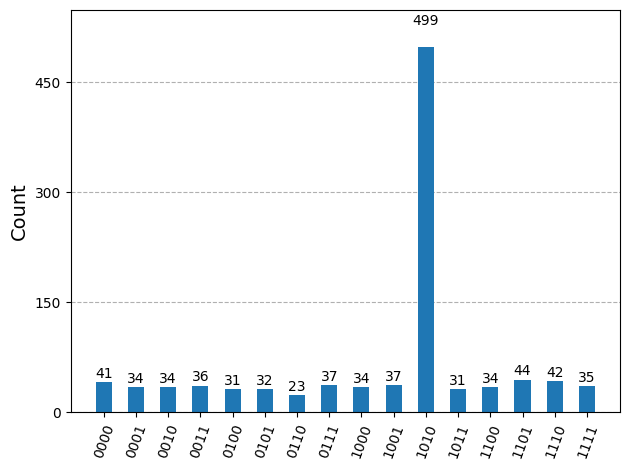

In [11]:
counts = ga.compute()
plot_histogram(counts)

## 2. Dinner Party

This demonstrates how the Grover’s algorithm identifies the valid guest list by considering all combinations simultaneously in superposition.

By using a logical oracle to "mark" satisfying states with a phase flip and an amplification step to boost their probability, this ultimately provides a quadratic speedup over classical searching.

##### Steps

1. Put all possible guest lists (e.g., 32 for 5 guests) into equal superposition.
2. The **Oracle** marks valid lists by flipping their phase.
3. Diffusion reflects about the average, boosting marked states.
4. **Measure**: the valid list appears with high probability.

In [12]:
!pip3 install qiskit-algorithms --break-system-packages

In [22]:
from qiskit.circuit.library import PhaseOracle
from qiskit_algorithms import Grover, AmplificationProblem
from qiskit.primitives import StatevectorSampler

# 1. Logic
logical_expression = '((James & Lars) | (Kirk | Lena)) & ~Rob & ~Lena'
names = sorted(['James', 'Lars', 'Kirk', 'Rob', 'Lena']) 
oracle = PhaseOracle(logical_expression, var_order=names)

# 2. Problem & Grover
problem = AmplificationProblem(oracle, is_good_state=oracle.evaluate_bitstring)
sampler = StatevectorSampler(seed=42) 
grover = Grover(sampler=sampler, iterations=1)

# 3. Run
result = grover.amplify(problem)

# 4. Corrected Results Loop
print(f"Variable Order (q0 to q4): {names}\n")
counts = result.circuit_results[0]
total_invited = set()

for key, prob in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    if prob > 0.07:
        found_high_prob = True
        # Handle key as string or int
        bitstring = key if isinstance(key, str) else format(key, f'0{len(names)}b')
        
        # Reverse for Little-Endian mapping (q0 is index 0 in names)
        bits_reversed = bitstring[::-1]
        invited = [names[i] for i, bit in enumerate(bits_reversed) if bit == '1']
        total_invited = total_invited.union(invited)
        
print(f"CONFIRMED GUESTS (Prob: {prob:.2%})")
print(f"Invited: {', '.join(total_invited)}")

Variable Order (q0 to q4): ['James', 'Kirk', 'Lars', 'Lena', 'Rob']

CONFIRMED GUESTS (Prob: 0.20%)
Invited: Lars, James, Kirk


/var/folders/td/rtvtvvjn3x1gfqswnc7bb6hm0000gn/T/ipykernel_15690/1965029848.py:8: DeprecationWarning: The class ``qiskit.circuit.library.phase_oracle.PhaseOracle`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.PhaseOracleGate instead.
  oracle = PhaseOracle(logical_expression, var_order=names)
